FoodHub Data Analysis





### Context

The number of restaurants in New York is increasing day by day. Lots of students and busy professionals rely on those restaurants due to their hectic lifestyles. Online food delivery service is a great option for them. It provides them with good food from their favorite restaurants. A food aggregator company FoodHub offers access to multiple restaurants through a single smartphone app.

The app allows the restaurants to receive a direct online order from a customer. The app assigns a delivery person from the company to pick up the order after it is confirmed by the restaurant. The delivery person then uses the map to reach the restaurant and waits for the food package. Once the food package is handed over to the delivery person, he/she confirms the pick-up in the app and travels to the customer's location to deliver the food. The delivery person confirms the drop-off in the app after delivering the food package to the customer. The customer can rate the order in the app. The food aggregator earns money by collecting a fixed margin of the delivery order from the restaurants.

### Objective

The food aggregator company has stored the data of the different orders made by the registered customers in their online portal. They want to analyze the data to get a fair idea about the demand of different restaurants which will help them in enhancing their customer experience. Suppose you are hired as a Data Scientist in this company and the Data Science team has shared some of the key questions that need to be answered. Perform the data analysis to find answers to these questions that will help the company to improve the business.

### Data Description

The data contains the different data related to a food order. The detailed data dictionary is given below.

### Data Dictionary

* order_id: Unique ID of the order
* customer_id: ID of the customer who ordered the food
* restaurant_name: Name of the restaurant
* cuisine_type: Cuisine ordered by the customer
* cost: Cost of the order
* day_of_the_week: Indicates whether the order is placed on a weekday or weekend (The weekday is from Monday to Friday and the weekend is Saturday and Sunday)
* rating: Rating given by the customer out of 5
* food_preparation_time: Time (in minutes) taken by the restaurant to prepare the food. This is calculated by taking the difference between the timestamps of the restaurant's order confirmation and the delivery person's pick-up confirmation.
* delivery_time: Time (in minutes) taken by the delivery person to deliver the food package. This is calculated by taking the difference between the timestamps of the delivery person's pick-up confirmation and drop-off information

### Let us start by importing the required libraries

In [ ]:
# import libraries for data manipulation
import numpy as np
import pandas as pd

# import libraries for data visualization
import matplotlib.pyplot as plt
import seaborn as sns

### Understanding the structure of the data

In [ ]:
# read the data
df = pd.read_csv('foodhub_order.csv')
# returns the first 5 rows
df.head()

,order_id,customer_id,restaurant_name,cuisine_type,cost_of_the_order,day_of_the_week,rating,food_preparation_time,delivery_time
0,1477147,337525,Hangawi,Korean,30.75,Weekend,Not given,25,20
1,1477685,358141,Blue Ribbon Sushi Izakaya,Japanese,12.08,Weekend,Not given,25,23
2,1477070,66393,Cafe Habana,Mexican,12.23,Weekday,5,23,28
3,1477334,106968,Blue Ribbon Fried Chicken,American,29.20,Weekend,3,25,15
4,1478249,76942,Dirty Bird to Go,American,11.59,Weekday,4,25,24


#### Observations:

The DataFrame has 9 columns as mentioned in the Data Dictionary. Data in each row corresponds to the order placed by a customer.

Understanding Dataset Structure

In [ ]:
#The code will gather the overall structure of the dataset. Giving the number of rows and columns.#
df.shape

(1898, 9)

Observations: The dataset consists of 9 columns with 1,898 rows.


Examining Variable Types

In [ ]:
#This code gives a summary of the dataset's structure.#
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


Observations: The dataset contains 4 object columns, 5 columns containing integers, and 3 columns containg floats.


Assessing Data Quality

In [ ]:
#The code checks to see if there are blank cells with missing values and summarizes them by column.#
df.isnull().sum()

,0
order_id,0
customer_id,0
restaurant_name,0
cuisine_type,0
cost_of_the_order,0
day_of_the_week,0
rating,0
food_preparation_time,0
delivery_time,0


Observations: There are 0 missing values in the dataset.


Evaluating Food Preparation Times

In [ ]:
#The code calculates the minumum, average, and maximum time of the varialble.#
df['food_preparation_time'].agg(['min', 'mean', 'max'])

,food_preparation_time
min,20.00000
mean,27.37197
max,35.00000


Observations: The minimum time to prepare the food is 20 minutes. The maximum time is 35 minutes. While the average time to prepare the food is slightly over 27 minutes.


Analyzing Customer Rating Participation

In [ ]:
#The code checks to see if there are blank cells wiht missing values and sums the number#
df['rating'].isnull().sum()

np.int64(0)

Observations: There are 0 missing values.


### Exploratory Data Analysis (EDA)

### Univariate Analysis

Exploring Key Operational Variables

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1898 entries, 0 to 1897
Data columns (total 9 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   order_id               1898 non-null   int64  
 1   customer_id            1898 non-null   int64  
 2   restaurant_name        1898 non-null   object 
 3   cuisine_type           1898 non-null   object 
 4   cost_of_the_order      1898 non-null   float64
 5   day_of_the_week        1898 non-null   object 
 6   rating                 1898 non-null   object 
 7   food_preparation_time  1898 non-null   int64  
 8   delivery_time          1898 non-null   int64  
dtypes: float64(1), int64(4), object(4)
memory usage: 133.6+ KB


In [ ]:
df.describe()

,order_id,customer_id,cost_of_the_order,food_preparation_time,delivery_time,rating_num,revenue,total_time
count,1.898000e+03,1898.000000,1898.000000,1898.000000,1898.000000,1162.000000,1898.000000,1898.000000
mean,1.477496e+06,171168.478398,16.498851,27.371970,24.161749,4.344234,18.442333,51.533720
std,5.480497e+02,113698.139743,7.483812,4.632481,4.972637,0.741478,10.335165,6.833603
min,1.476547e+06,1311.000000,4.470000,20.000000,15.000000,3.000000,4.470000,35.000000
25%,1.477021e+06,77787.750000,12.080000,23.000000,20.000000,4.000000,12.080000,47.000000
50%,1.477496e+06,128600.000000,14.140000,27.000000,25.000000,5.000000,14.140000,52.000000
75%,1.477970e+06,270525.000000,22.297500,31.000000,28.000000,5.000000,27.871875,56.000000
max,1.478444e+06,405334.000000,35.410000,35.000000,33.000000,5.000000,44.262500,68.000000


In [ ]:
#order_id and Customer_id are identifiers used for tracking#

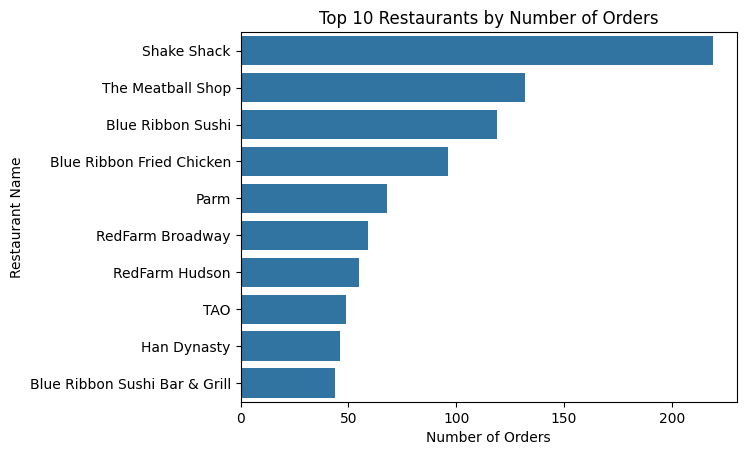

In [ ]:
#The code creates a barpot showing the number of orders for the top 10 restaurants.#
top_10 = df['restaurant_name'].value_counts().head(10)
sns.barplot(
    x=top_10.values,
    y=top_10.index)
plt.xlabel("Number of Orders")
plt.ylabel("Restaurant Name")
plt.title("Top 10 Restaurants by Number of Orders")
plt.show()

Observation: The Shake Shack shows the most orders while Blue Ribbon Sushi Bar & Grill is showing the least.

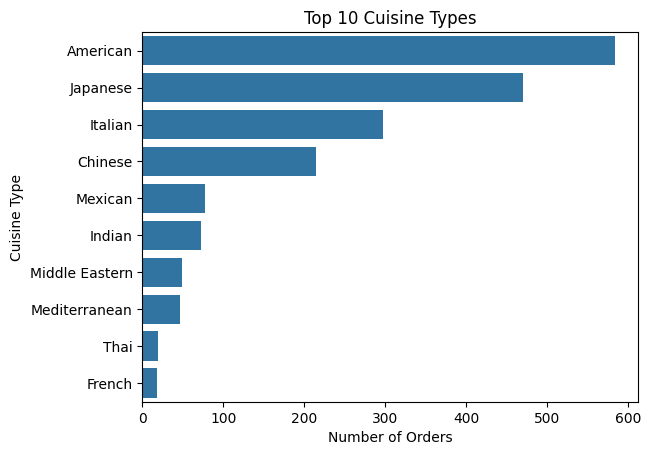

In [ ]:
#The code creates a barplot shwoing the number of orders for the top 10 cuisine types.#
top_cuisines = df['cuisine_type'].value_counts().head(10)
sns.barplot(
    x=top_cuisines.values,
    y=top_cuisines.index)
plt.xlabel("Number of Orders")
plt.ylabel("Cuisine Type")
plt.title("Top 10 Cuisine Types")
plt.show()

Observations: The American cuisine is ordered the most frequently while French cuisine is ordered the least.

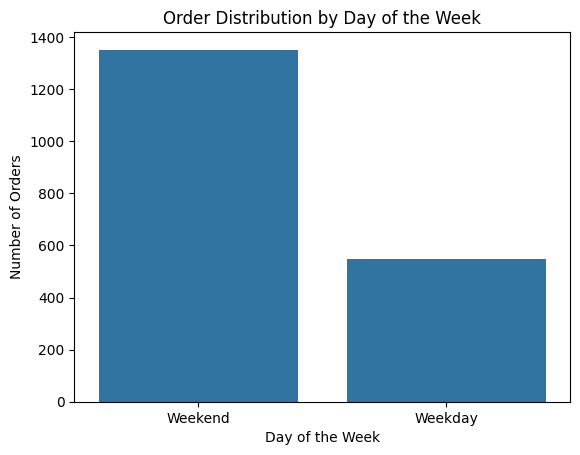

In [ ]:
#The countplot show the number of orders on the Weekend and the number of orders on weekdays.#
sns.countplot(x='day_of_the_week', data=df)
plt.xlabel("Day of the Week")
plt.ylabel("Number of Orders")
plt.title("Order Distribution by Day of the Week")
plt.show()

Observations: There are more orders occuring during the weekend.

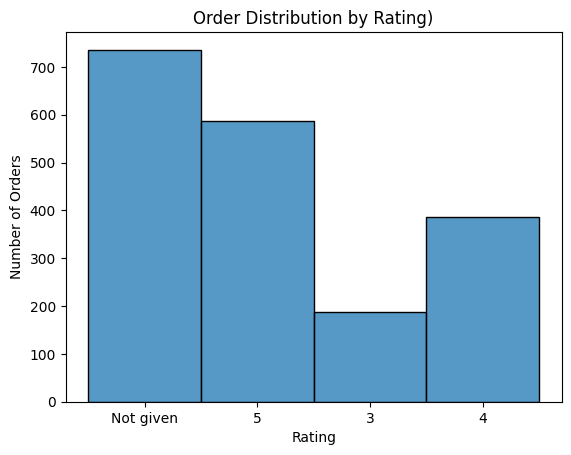

In [ ]:
#The histogram shows the number of orders by each rating.#
sns.histplot(x='rating', data=df)
plt.xlabel("Rating")
plt.ylabel("Number of Orders")
plt.title("Order Distribution by Rating)")
plt.show()

Observations: No ratings are given the majority of the time. A rating of 2 is not given.

Text(0.5, 1.0, 'Distribution of Food Preparation Time')

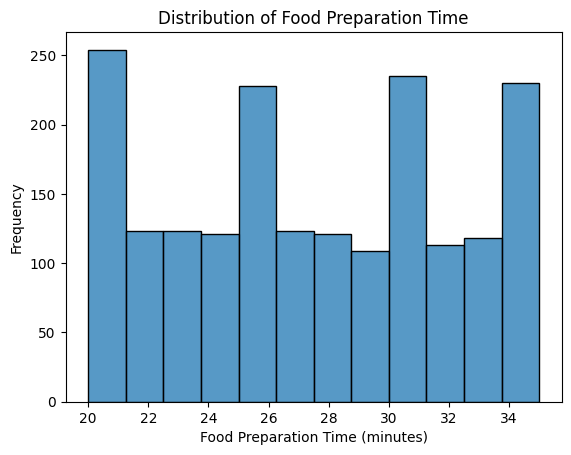

In [ ]:
#The histogram shows how often an order takes x amount of minutes.#
sns.histplot(x='food_preparation_time', data=df)
plt.xlabel("Food Preparation Time (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Food Preparation Time")

Observations: Most food is prepared in 20 minutes.

Text(0.5, 1.0, 'Distribution of Delivery Time')

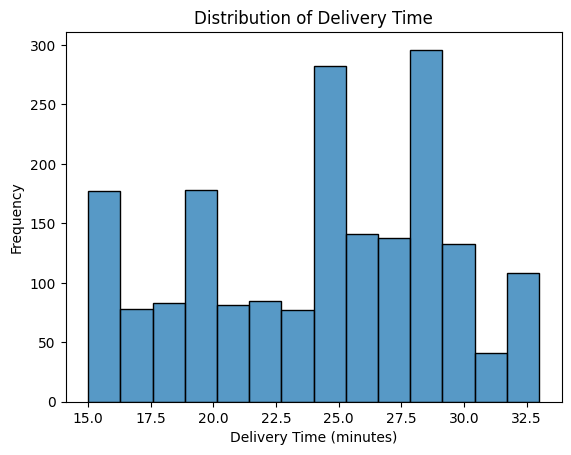

In [ ]:
#The histogram shows how often a delivery time occurs.#
sns.histplot(x='delivery_time', data=df)
plt.xlabel("Delivery Time (minutes)")
plt.ylabel("Frequency")
plt.title("Distribution of Delivery Time")

Observations: Delivery time most frequently occurs around 28 minutes.

Text(0.5, 1.0, 'Distribution of Cost of the Order')

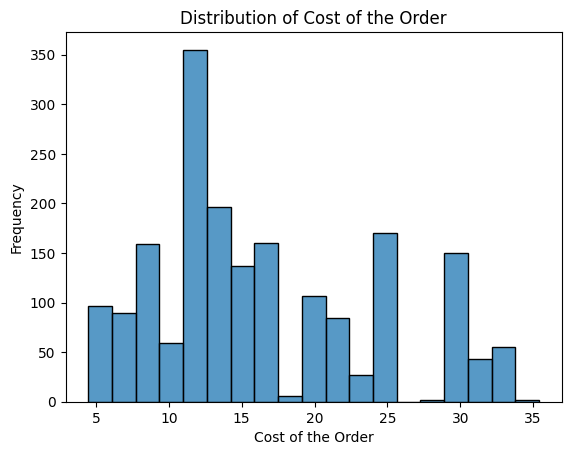

In [ ]:
#The code shows the distribution of order costs.#
sns.histplot(x='cost_of_the_order', data=df)
plt.xlabel("Cost of the Order")
plt.ylabel("Frequency")
plt.title("Distribution of Cost of the Order")

Observation: It appears several cuisines occur roughly the same number of times more often on the weekend.

Text(0.5, 1.0, 'Order Distribution by Day of the Week')

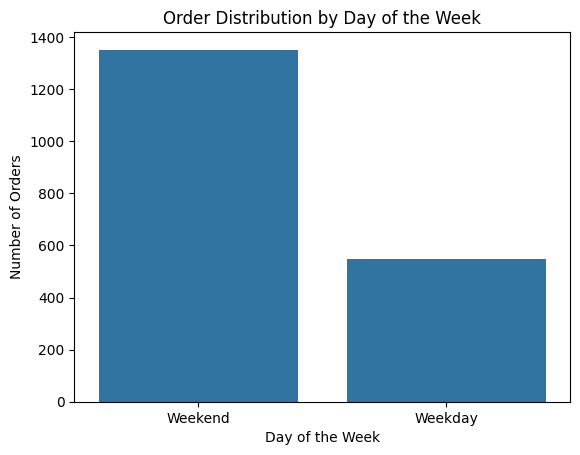

In [ ]:
#The countplot compares the order volumn on weekdays versus the weekends.#
sns.countplot(x='day_of_the_week', data=df)
plt.xlabel("Day of the Week")
plt.ylabel("Number of Orders")
plt.title("Order Distribution by Day of the Week")

Observation: There are more than twice as many orders occuring on the weekends.

Text(0.5, 1.0, 'Order Distribution by Delivery Time')

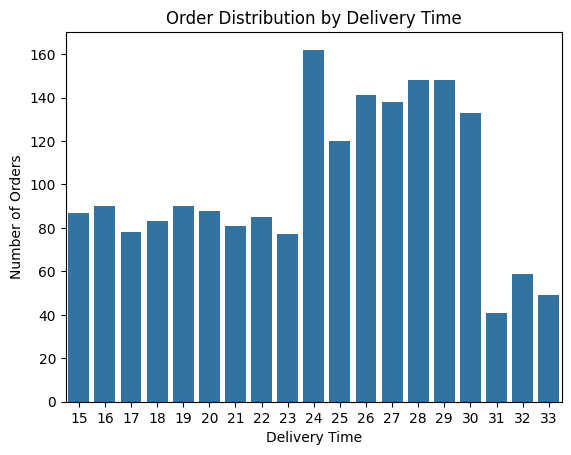

In [ ]:
#The countplot shows the order delivery time by the number of orders occuring.#
sns.countplot(x='delivery_time', data=df)
plt.xlabel("Delivery Time")
plt.ylabel("Number of Orders")
plt.title("Order Distribution by Delivery Time")

Observation: During the height of order number it seems that the average delivery time is 24 minutes.

Determine the top five restaurants by order volume to identify the most popular establishments on the platform.

In [ ]:
#The code selects the variable and counts how many times the variable appears in the column. The addition of .head() looks for the top 5 most frequent occurrances of that variable.#
df['restaurant_name'].value_counts().head(5)

,count
restaurant_name,
Shake Shack,219
The Meatball Shop,132
Blue Ribbon Sushi,119
Blue Ribbon Fried Chicken,96
Parm,68


Observations: The top 5 resturant names would be Shake Shack, The Meatball Shop, Blue Ribbin Sushi, Blue Ribbon Fried Chicken, and Parm.


Weekend Cuisine Popularity

In [ ]:
#The code selects the dataframe and checks which rows occur on the weekend. It then selects a variable from the weekend rows and counts how many times the variable occurs on the weekend and identifies the most frequent.#
df[df['day_of_the_week'] == 'Weekend']['cuisine_type'].value_counts().idxmax()

'American'

Observations: American cuisine is the most popular.


High-Value Orders

In [ ]:
#The code creates a Boolean series and calculates the mean and converts it to a perecntage.#
(df['cost_of_the_order'] > 20).mean() * 100

np.float64(29.24130663856691)

Observations: The mean cost of the orders tha cost more than 20 dollars are 29 percent.


Delivery Time Performance

In [ ]:
#The code selects the dataframe and finds the mean of the variable.#
df['delivery_time'].mean()

np.float64(24.161749209694417)

Observations: The average delivery time for order delivery is 24 minutes.


Most Frequent Customers

In [ ]:
#The code identifies the top most occurring values.#
df['customer_id'].value_counts().head(3)


,count
customer_id,
52832,13
47440,10
83287,9


Observations: The top 3 most frequent customers.


### Multivariate Analysis

Multivariate Relationship Analysis

<Axes: xlabel='food_preparation_time', ylabel='delivery_time'>

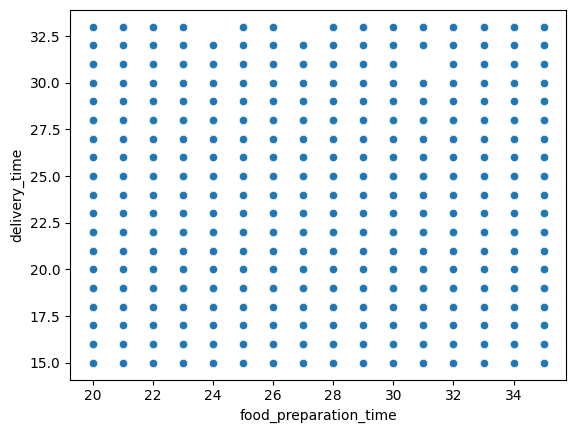

In [ ]:
#The scatterplot looks for a relationship between food prep time and delivery time.#
sns.scatterplot(x=df['food_preparation_time'], y=df['delivery_time']
)

Observation: There does not appear to be a relationship between food prep time and delivery time.

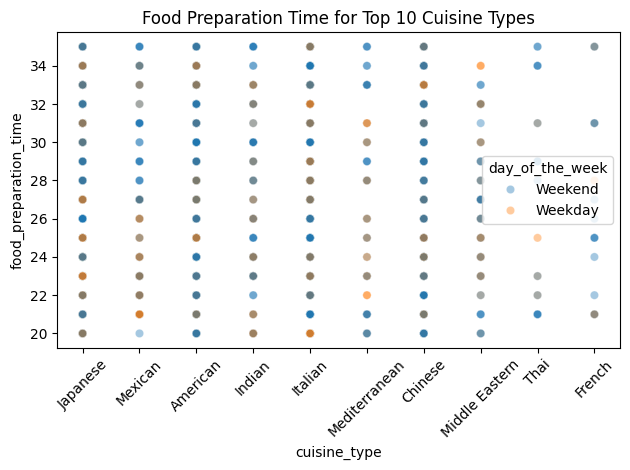

In [ ]:
#The scatterplot filters the top 10 cuisine and compares to the preparation time while denoting the weekdays or weekends.#
top_10 = df['cuisine_type'].value_counts().head(10).index
df_top = df[df['cuisine_type'].isin(top_10)]
sns.scatterplot(
    x='cuisine_type',
    y='food_preparation_time',
    hue='day_of_the_week',
    data=df_top,
    alpha=0.4)
plt.xticks(rotation=45)
plt.title("Food Preparation Time for Top 10 Cuisine Types")
plt.tight_layout()
plt.show()

Observation: Several cuisine times are lightly correlated to the food prep time. It seems the food prep time is most impacted on the weekend.

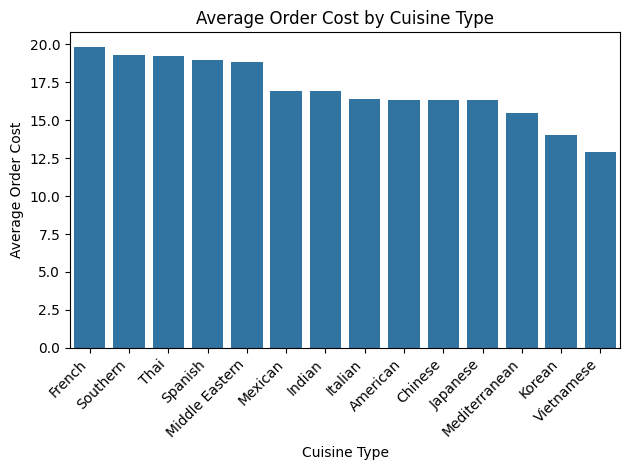

In [ ]:
#The barplot shows the average cost of the order based on cuisine type.#
average_cost_by_cuisine = df.groupby('cuisine_type')['cost_of_the_order'].mean().reset_index()
average_cost_by_cuisine = average_cost_by_cuisine.sort_values(by='cost_of_the_order', ascending=False)
sns.barplot(
    x='cuisine_type',
    y='cost_of_the_order',
    data=average_cost_by_cuisine)
plt.xticks(rotation=45, ha='right')
plt.title("Average Order Cost by Cuisine Type")
plt.xlabel("Cuisine Type")
plt.ylabel("Average Order Cost")
plt.tight_layout()
plt.show()

Observation: French cuisine appears to have the highest average cost.

<Axes: xlabel='food_preparation_time', ylabel='cost_of_the_order'>

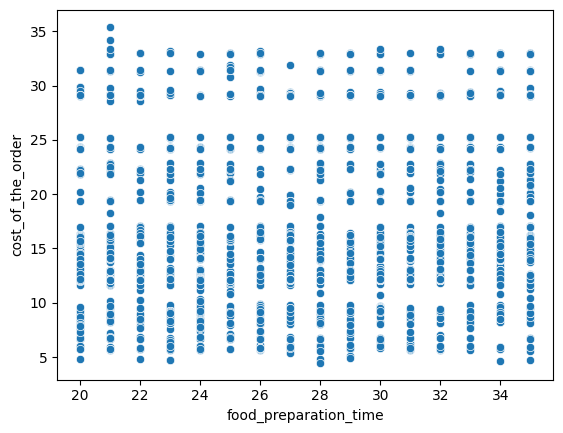

In [ ]:
#The scatterplot looks for a relationship between food prep time and cost of the order.#
sns.scatterplot(x=df['food_preparation_time'], y=df['cost_of_the_order']
)

Observation: Food preparation time appears to have a mild correlation to the cost of the order.

<Axes: xlabel='delivery_time', ylabel='cost_of_the_order'>

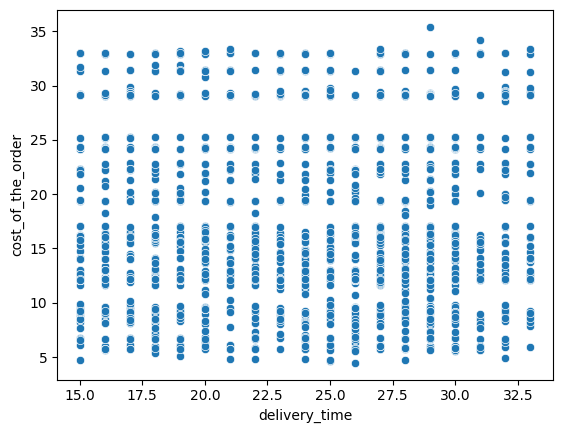

In [ ]:
#The scatterplot looks for a relationship between delivery time and cost of the order.#
sns.scatterplot(x=df['delivery_time'], y=df['cost_of_the_order']
)

Observation: Delivery time appears to have a mild correlation to the cost of the order.

<Axes: xlabel='rating', ylabel='food_preparation_time'>

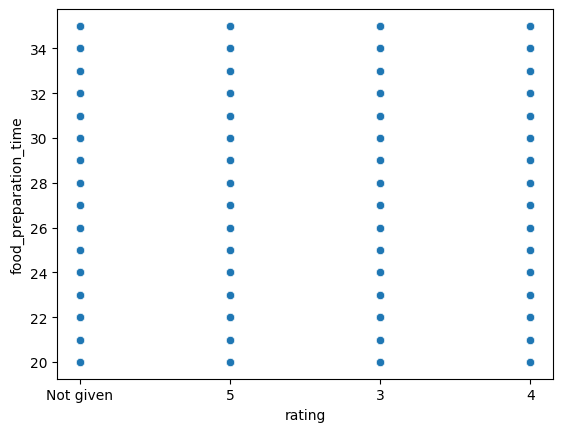

In [ ]:
#The scatterplot looks for a relationship between the rating and food prep time.#
sns.scatterplot(x=df['rating'], y=df['food_preparation_time']
)

Observation: There appears to be no correlation between the rating and the food preparation time.

<Axes: xlabel='rating', ylabel='delivery_time'>

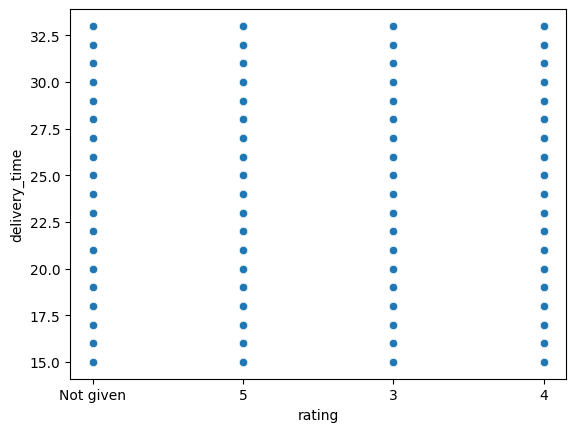

In [ ]:
#The scatterplot looks for a relationship between the rating and delivery time.#
sns.scatterplot(x=df['rating'], y=df['delivery_time']
)

Observation: There does not appear to be a correlation between the rating and the delivery time.

Identify restaurants that qualify for a promotional advertising offer by selecting those with more than 50 customer ratings and an average rating above 4, indicating consistently high customer satisfaction and strong engagement.

In [ ]:
#This code cleans the rating data and groups by resturant. It then calculates the count and average of the ratings for each restaurant while identifying resturants with more than 50 ratings and having an average above 4.#
df['rating_num'] = pd.to_numeric(df['rating'], errors='coerce')
rated = df.dropna(subset=['rating'])
summary = rated.groupby('restaurant_name').agg({'rating_num': ['count', 'mean']})
summary.columns = ['rating_count', 'rating_mean'] # Rename columns for easier access
qualified = summary[(summary['rating_count'] > 50) & (summary['rating_mean'] > 4)]
print(summary)

                  rating_count  rating_mean
restaurant_name                            
'wichcraft                   1     5.000000
12 Chairs                    2     4.500000
5 Napkin Burger              2     4.000000
67 Burger                    1     5.000000
Alidoro                      0          NaN
...                        ...          ...
Zero Otto Nove               1     4.000000
brgr                         1     3.000000
da Umberto                   1     5.000000
ilili Restaurant            13     4.153846
indikitch                    2     4.500000

[178 rows x 2 columns]


Observations: This shows the average ratings for each restaurant.


Calculate the total revenue generated by the platform by applying commission rates of 25% on orders exceeding $20 and 15% on orders exceeding $5, in order to estimate the company’s earnings from all processed orders.

In [ ]:
#The code creates and additional column dedicated to revenue and applies a 25 percent increast to orders more than 20 dollars, then totals the revanue to all orders.#
df['revenue'] = df['cost_of_the_order']
df.loc[df['cost_of_the_order'] > 20, 'revenue'] *= 1.25
df.sum()

,0
order_id,2804286459
customer_id,324877772
restaurant_name,HangawiBlue Ribbon Sushi IzakayaCafe HabanaBlu...
cuisine_type,KoreanJapaneseMexicanAmericanAmericanIndianIta...
cost_of_the_order,31314.82
day_of_the_week,WeekendWeekendWeekdayWeekendWeekdayWeekdayWeek...
rating,Not givenNot given5343Not given355Not given553...
food_preparation_time,51952
delivery_time,45859
rating_num,5048.0


Observations: The newly formed Revenue column shows a total revenue of $35,003.55.


Determine the percentage of orders that require more than 60 minutes from placement to delivery by analyzing the combined preparation and delivery times, in order to assess overall service efficiency.

In [ ]:
#The code calculats the total time for each order and calculates the percentage of orders that take more than 60 minutes.#
df['total_time'] = df['food_preparation_time'] + df['delivery_time']
(df['total_time'] > 60).mean() * 100

np.float64(10.537407797681771)

Observations: 10.5% of the orders take more than 60 minutes.


Compare the average delivery time for orders placed on weekdays and weekends to identify differences in delivery performance across these time periods.

In [ ]:
#The code groups the data and day of the week. Then it calculates the average delivery time for each group.#
df.groupby('day_of_the_week')['delivery_time'].mean()

,delivery_time
day_of_the_week,
Weekday,28.340037
Weekend,22.470022


Observations: The average delivery time during the wek is 28 mintes. During the weekend the average delivery time is 22 minutes.


### Conclusion and Recommendations

Synthesize the findings from the analysis to identify key operational insights and develop recommendations that could improve business performance, customer satisfaction, and strategic decision-making, particularly using patterns in cuisine demand and customer ratings.

###Conclusions:
*  The order volumn varies by day of the week showing more than twice as many orders placed on the weekend.
* The delivery and food preparation time shows a weak relationship to ratings and cost.
* Customer ratings appear consistant.
* The type of cuisine shows a relationship to cost, ratings and preparation times.
* Strong impact on customer satisfaction is not appearant.

### Recommendations:

*  Optimize staffing during peak periods.
*  Reduce complexity of the menu and focus on the cuisine with more common ingrediants.
* Prioritize most popular cuisines.
* Conduct quarterly evaluations.

---